<h1 style="text-align: center; text-decoration: underline;">
<strong>Impact of Brexit on the Stock Prices of BP and EasyJet</strong>
</h1>

<p style="text-align: center; font-style: italic; font-size: 20px; margin-top: -10px;">
A project by Winston Voguet 
</p>


This project investigates the impact of Brexit on the stock prices of two major UK companies: 
**British Petroleum (BP)** and **EasyJet**.
    
Using monthly stock price data from 2017 to 2023 found on Yahoo Fiance, the goal was to determine whether Brexit led to a significant change in stock price levels and volatility as well as whether the effect differed between the two companies. To do so, we conducted a anlysis using Python, more precisely Pandas for the data handling, NumPy for the numerical computations, and Matplotlib for data visualization (graphs, plots etc)



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Data Description

The dataset consists of monthly stock prices for BP and EasyJet from January 1st 2017 to December 31 2023, where for each company, the opening stock price at the beginning of each month is used.                              
As precised in the introduction, this data was obtained from Yahoo Finance, before then being stored locally as CSV files ('bp.csv' and 'easyjet.csv' respectfully)

To study the impact of Brexit, the dataset is divided into two periods:
- **Pre-Brexit:** January 2017 to January 2020  
- **Post-Brexit:** February 2020 to December 2023  

This split allows a direct comparison of stock price behavior before and after Brexit.

    
The final dataset consists of monthly observations with the following structure:
- One row per month
- Columns include the date and the opening stock prices of BP and EasyJet
After merging, the dataset contains one time-series for each company aligned by date.



In [3]:
bp = pd.read_csv("bp.csv")  # loads BP stock price data from the CSV file
easyjet = pd.read_csv("easyjet.csv") # loads easyjet stock price data from the CSV file

bp.head(), easyjet.head() # displays the first elements/rows of the data sets in order to showcast what they contain and check structure/content


(         Date    Open
 0  2017-01-01  509.60
 1  2017-02-01  477.55
 2  2017-03-01  458.95
 3  2017-04-01  460.35
 4  2017-05-01  442.50,
          Date    Open
 0  2017-01-01  1005.0
 1  2017-02-01   948.5
 2  2017-03-01   961.0
 3  2017-04-01  1023.0
 4  2017-05-01  1168.0)

In [4]:
bp["Date"] = pd.to_datetime(bp["Date"]) # converts Date column to datetime form which allows proper time-series sorting/plotting for the bp data
easyjet["Date"] = pd.to_datetime(easyjet["Date"]) # same as above but this time for easyjet 

bp = bp.sort_values("Date") #sorts BP data chronogically 
easyjet = easyjet.sort_values("Date") # sorts EasyJet's data chronogically


In [5]:
df = pd.merge(bp, easyjet, on="Date", how="inner")# combines BP and EasyJet data by matching rows with the same Date value in both datasets
df.rename(columns={"Open_x": "BP_Open", "Open_y": "EZJ_Open"}, inplace=True) # renames columns created by the merge to clearly identify each company
df.head() # checks that the merge worked correctly by displaying the first rows to check the content/structure 

,Date,BP_Open,EZJ_Open
0,2017-01-01,509.60,1005.0
1,2017-02-01,477.55,948.5
2,2017-03-01,458.95,961.0
3,2017-04-01,460.35,1023.0
4,2017-05-01,442.50,1168.0


# Dealing with possible missing values

In [6]:
df.isnull().sum() #checks for missing values in each column of the dataset


Date        0
BP_Open     0
EZJ_Open    0
dtype: int64

--> No missing values were found in the dataset, so no additional data cleaning was required.

## Time-Series Analysis

    Since Brexit can be observed as a specific event over/in time, the first step of the analysis is to look at how the stock prices of BP and EasyJet evolve over the entire period from Brexit was in process, ie from 2017 to 2023. Plotting the prices as a time series allows us to visually identify when major changes occur and whether there is a noticeable shift around the Brexit period. 
    This representation also makes it possible to compare the overall behavior of the two companies: whether they follow similar trends, how volatile they are, and whether one appears more sensitive to economic uncertainty than the other.



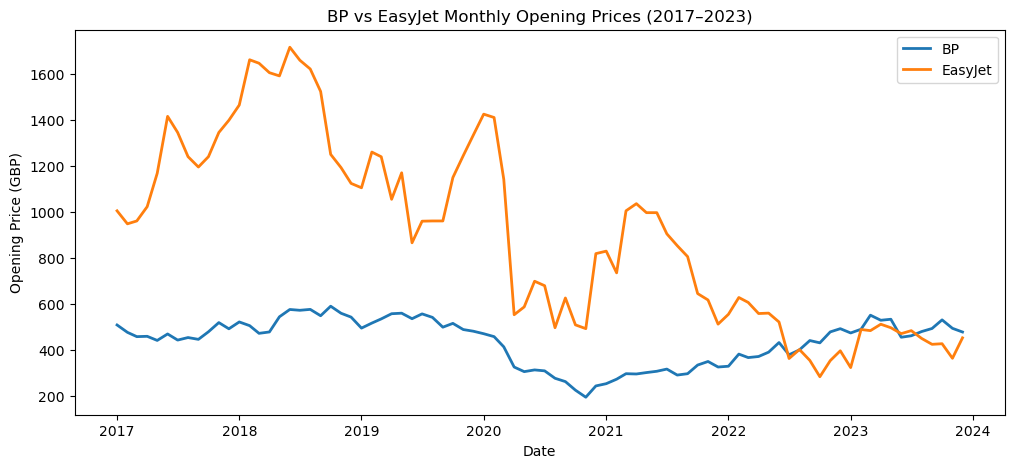

In [7]:
#plots BP and EasyJet's respective monthly opening prices over time 
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["BP_Open"], label="BP", linewidth=2) 
plt.plot(df["Date"], df["EZJ_Open"], label="EasyJet", linewidth=2) 

plt.xlabel("Date")
plt.ylabel("Opening Price (GBP)")
plt.title("BP vs EasyJet Monthly Opening Prices (2017–2023)")
plt.legend()

plt.show()


The line plots clearly show contrasting volatility patterns:

BP exhibits relatively smooth price movements.

EasyJet shows sharp drops and rebounds, especially around 2020–2021.

## Pre and Post Brexit Period Definition

    To evaluate the impact of Brexit, the dataset is divided into two periods : pre and post Brexit. 
    Since the data is monthly, February 2020 is treated as the first month of the post-Brexit period, while January 2020 remains part of the pre-Brexit period. This choice allows a consistent comparison of stock prices before and after Brexit.


In [8]:
brexit_date = pd.to_datetime("2020-02-01")# defines the start of the post-Brexit period for monthly data
df_pre = df[df["Date"] < brexit_date] # keeps observations from the pre-Brexit period
df_post = df[df["Date"] >= brexit_date] # keeps observations from the post-Brexit period

len(df_pre), len(df_post) # checks how many months there are in the Pre (approximately 37 months) and Post (47) Brexit period respectively 


(37, 47)

# Comparing the average opening stock prices before and after Brexit for both companies.


In [9]:
bp_pre_mean = df_pre["BP_Open"].mean()#average BP price before Brexit
bp_post_mean = df_post["BP_Open"].mean()#average BP price after Brexit

bp_pre_median = df_pre["BP_Open"].median()#median BP price before Brexit
bp_post_median = df_post["BP_Open"].median()#median BP price after Brexit

bp_pre_std = df_pre["BP_Open"].std()#BP volatility before Brexit
bp_post_std = df_post["BP_Open"].std()#BP volatility after Brexit

ez_pre_mean = df_pre["EZJ_Open"].mean()#average EasyJet opening price before Brexit
ez_post_mean = df_post["EZJ_Open"].mean()#average EasyJet opening price after Brexit

ez_pre_median = df_pre["EZJ_Open"].median()#median EasyJet opening price before Brexit
ez_post_median = df_post["EZJ_Open"].median()#median EasyJet opening price after Brexit

ez_pre_std = df_pre["EZJ_Open"].std() #EasyJet price volatility before Brexit
ez_post_std = df_post["EZJ_Open"].std() #EasyJet price volatility after Brexit

bp_pre_mean, bp_post_mean, bp_pre_std, bp_post_std, ez_pre_mean, ez_post_mean, ez_pre_std, ez_post_std

(np.float64(511.44594594594594),
 np.float64(380.65531914893614),
 42.799408385024535,
 94.88508280274031,
 np.float64(1271.9378378378378),
 np.float64(615.9212765957446),
 240.5648299677603,
 240.44231156275143)

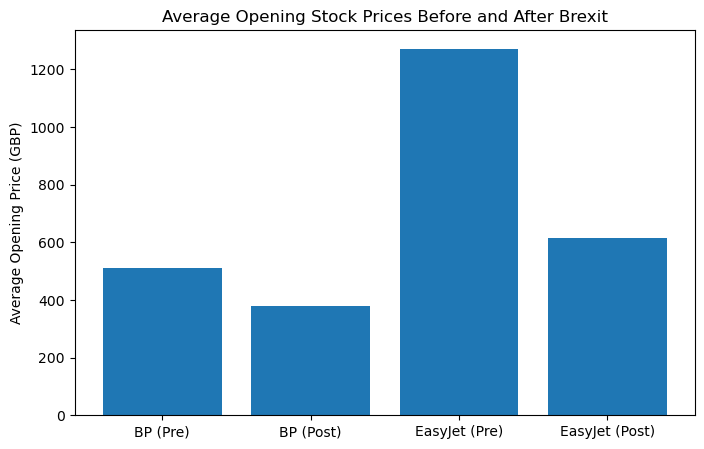

In [10]:
#Bar plot to compare average opening prices before and after Brexit

companies = ["BP (Pre)", "BP (Post)", "EasyJet (Pre)", "EasyJet (Post)"]
means = [bp_pre_mean, bp_post_mean, ez_pre_mean, ez_post_mean]

plt.figure(figsize=(8,5))
plt.bar(companies, means)
plt.ylabel("Average Opening Price (GBP)")
plt.title("Average Opening Stock Prices Before and After Brexit")
plt.show()


Both companies experience a clear decline in mean prices after Brexit:

BP: moderate decrease.

EasyJet: large and abrupt decrease.

## Measuring Price Dispersion with the Interquartile Range (IQR)

    In addition to the mean and standard deviation, the interquartile range (IQR) is used to measure how spread out stock prices are for most observations. 
    Unlike the standardeviation, the IQR focuses on the middle 50% of the data and is therefore less affected by extreme price movements, which thus makes it particularly useful for understanding whether typical price variability increased after Brexit, rather than volatility being driven by only a few extreme months.


In [11]:
# Quartiles and IQR for BP and Easyjet respectively (typical price dispersion)

bp_Q1_pre = df_pre["BP_Open"].quantile(0.25) # first quartile: value below which 25% of BP prices fall before Brexit
bp_Q3_pre = df_pre["BP_Open"].quantile(0.75) # third quartile: value below which 75% of BP prices fall before Brexit
bp_IQR_pre = bp_Q3_pre - bp_Q1_pre # interquartile range: spread of the middle 50% of BP prices before Brexit

# same for post-Brexit BP data
bp_Q1_post = df_post["BP_Open"].quantile(0.25)
bp_Q3_post = df_post["BP_Open"].quantile(0.75)
bp_IQR_post = bp_Q3_post - bp_Q1_post

# same but for easjy jet data both pre and post brexit
ez_Q1_pre = df_pre["EZJ_Open"].quantile(0.25)
ez_Q3_pre = df_pre["EZJ_Open"].quantile(0.75)
ez_IQR_pre = ez_Q3_pre - ez_Q1_pre

ez_Q1_post = df_post["EZJ_Open"].quantile(0.25)
ez_Q3_post = df_post["EZJ_Open"].quantile(0.75)
ez_IQR_post = ez_Q3_post - ez_Q1_post

bp_IQR_pre, bp_IQR_post, ez_IQR_pre, ez_IQR_post


(np.float64(67.55000000000001),
 np.float64(163.75),
 np.float64(319.5),
 np.float64(254.7499999999999))

## Distributional analysis with boxplots

    Boxplots are used to visualize the distribution of stock prices before and after Brexit by providing a graphical representation of the median, interquartile range (IQR), and potential outliers which allows a direct visual comparison of price dispersion across periods.


/var/folders/cx/53gms3v55sv_qlkvqlw5dwgr0000gn/T/ipykernel_12003/765619280.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_pre["BP_Open"], df_post["BP_Open"]], labels=["BP Pre", "BP Post"])
/var/folders/cx/53gms3v55sv_qlkvqlw5dwgr0000gn/T/ipykernel_12003/765619280.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_pre["EZJ_Open"], df_post["EZJ_Open"]], labels=["EZ Pre", "EZ Post"])


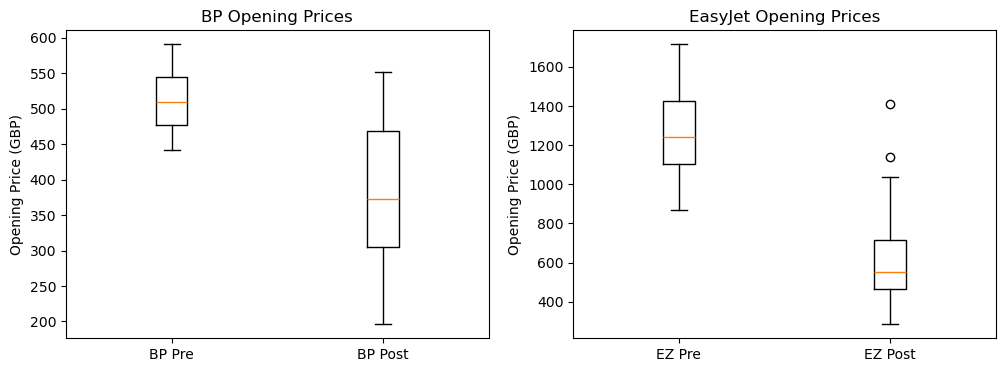

In [12]:
plt.figure(figsize=(12,4)) #creates a single figure wide enough for two boxplots as it has dimenstions 12 and 4 

# BP boxplot (left one)
plt.subplot(1, 2, 1)#first subplot: 1 row, 2 columns, position 1

plt.boxplot([df_pre["BP_Open"], df_post["BP_Open"]], labels=["BP Pre", "BP Post"])
plt.title("BP Opening Prices")
plt.ylabel("Opening Price (GBP)")

# EasyJet boxplot (right one)
plt.subplot(1, 2, 2) #second subplot: 1 row, 2 columns, position 2

plt.boxplot([df_pre["EZJ_Open"], df_post["EZJ_Open"]], labels=["EZ Pre", "EZ Post"])
plt.title("EasyJet Opening Prices")
plt.ylabel("Opening Price (GBP)")

plt.show()


These two figures confirm the results from the table. EasyJet experienced larger fluctuations in
share prices compared to BP. For EasyJet, we can see that before Brexit the data is symmetric,
as the median lies in the center of the box and the whiskers are nearly equal in length, indicating
balanced variability around the middle 50% of values. However, after Brexit we can see in the
EasyJet share that the right whisker is longer than the left whisker and the median is on the right
side of the box suggesting that it is positively skewed.  This skew indicates significant volatility
and larger upward changes in share prices since 25% of the values (from minimum to Q1) cover
a shorter range, but 25% of the values (between Q3 and the highest) cover a much broader
range. For BP, both boxes are in the middle and the whiskers are approximatively the same
sizes indicating that the data have a symmetric distribution, hence their market must be more
stable and less affected by Brexit.

## Correlation analysis

    After analyzing price levels and volatility, the next step is to examine whether BP and EasyJet stock prices tend to move together. 
    To do so, we reccured to Pearson's correlation analysis which helped in assesing the strength/degree and direction of the relationship between the two companies both pre and post Brexit.


In [13]:
corr_pre = df_pre["BP_Open"].corr(df_pre["EZJ_Open"])#computes the Pearson correlation between BP and EasyJet opening prices before Brexit by measuring whether the two stocks tend to move together during this period before brexit
corr_post = df_post["BP_Open"].corr(df_post["EZJ_Open"]) # same here but for the post brexit period 

corr_pre, corr_post

(np.float64(0.13954353337800326), np.float64(-0.41649339978761596))

# Scatter plots pre and post Brexit
    To better understand the correlation results, we used scatter plots to visualize the relationship between BP and EasyJet stock prices in each period of Brexit (before/after)

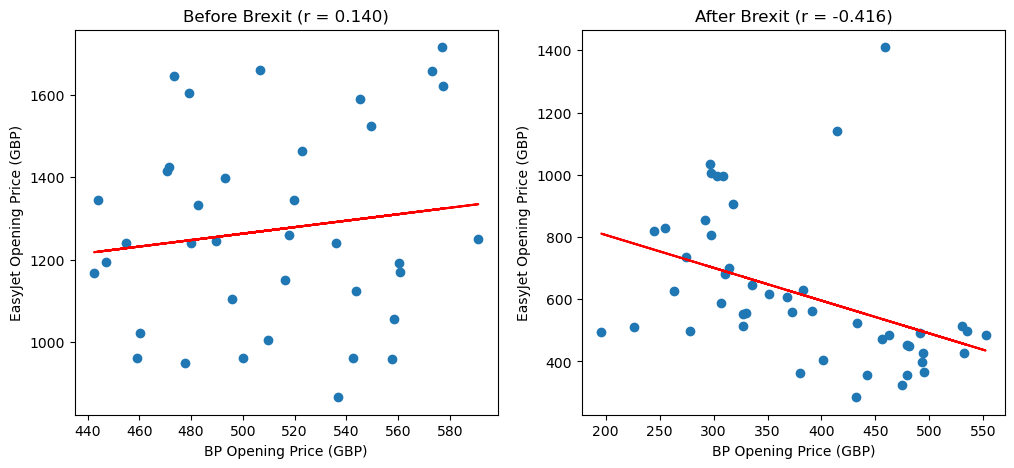

In [14]:
#Pre & Post Brexit correlation scatter plots
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1) # first subplot (left one : before Brexit period)
plt.scatter(df_pre["BP_Open"], df_pre["EZJ_Open"])#plots BP prices against EasyJet prices before Brexit
m_pre, b_pre = np.polyfit(df_pre["BP_Open"], df_pre["EZJ_Open"], 1) #fits a straight line approximating the relationship before Brexit
plt.plot(df_pre["BP_Open"], m_pre * df_pre["BP_Open"] + b_pre, color="red") # adds the fitted line to the scatter plot

plt.xlabel("BP Opening Price (GBP)")
plt.ylabel("EasyJet Opening Price (GBP)")
plt.title(f"Before Brexit (r = {corr_pre:.3f})")


plt.subplot(1, 2, 2) #second subplot (right one : after Brexit period) --> same as above but here we're focusing on the Post-Brexit period
plt.scatter(df_post["BP_Open"], df_post["EZJ_Open"])
m_post, b_post = np.polyfit(df_post["BP_Open"], df_post["EZJ_Open"], 1) 
plt.plot(df_post["BP_Open"], m_post * df_post["BP_Open"] + b_post, color="red") 

plt.xlabel("BP Opening Price (GBP)")
plt.ylabel("EasyJet Opening Price (GBP)")
plt.title(f"After Brexit (r = {corr_post:.3f})")

plt.show()


Before Brexit: very weak positive correlation → independent behavior.

After Brexit: moderate negative correlation.

we can see on figure 2 that the share
prices are less spread out and correlate negatively. This suggest that both companies suffered
from Brexit, furthermore before Brexit they were not correlated, after Brexit they have a
negative moderate correlation hence when one increases the other one decreases.

## Statistical comparison of means : computing Welch’s t-statistic

    To formally assess whether average stock prices differ before and after Brexit, a Welch t-test is used. 
    This test compares the means of two samples while allowing for different variances and sample sizes.


In [15]:
# BP
n1_bp = len(df_pre["BP_Open"]) #number of BP observations (months) before Brexit
n2_bp = len(df_post["BP_Open"]) #number of BP observations (months) after Brexit

mean1_bp = df_pre["BP_Open"].mean() #average BP opening price before Brexit
mean2_bp = df_post["BP_Open"].mean() #average BP opening price post Brexit

var1_bp = df_pre["BP_Open"].var(ddof=1) #sample variance of BP prices before Brexit (where ddof=1 is used for unbiased estimate)
var2_bp = df_post["BP_Open"].var(ddof=1) #sample variance of BP prices after Brexit 

# EasyJet
n1_ez = len(df_pre["EZJ_Open"]) #number of EasyJet observations (months) before Brexit
n2_ez = len(df_post["EZJ_Open"]) #number of EasyJet observations (months) after Brexit

mean1_ez = df_pre["EZJ_Open"].mean() #number of EasyJet monthly observations pre Brexit
mean2_ez = df_post["EZJ_Open"].mean() #number of EasyJet monthly observations post Brexit

var1_ez = df_pre["EZJ_Open"].var(ddof=1) #sample variance of EasyJet prices before Brexit
var2_ez = df_post["EZJ_Open"].var(ddof=1) #same but post brexit


In [16]:
def welch_t(mean1, mean2, var1, var2, n1, n2): #computes the Welch t-statistic by comparing the difference in means --> relative to variability and sample size in each group
    return (mean1 - mean2) / np.sqrt(var1/n1 + var2/n2)

t_bp = welch_t(bp_pre_mean, bp_post_mean, var1_bp, var2_bp, n1_bp, n2_bp) #measures how different BP prices are before vs after Brexit

t_ez = welch_t(ez_pre_mean, ez_post_mean, var1_ez, var2_ez, n1_ez, n2_ez) #measures how different EasyJet prices are before vs after Brexit

t_bp, t_ez


(np.float64(8.42383213459353), np.float64(12.410527459350838))

# Interpretation of the t-statistics

    The Welch t-statistic compares the mean stock price before and after Brexit for each company. The value of the t-statistic indicates how large the difference between the two averages is relative to the variability of the data.

    For BP, the t-value is approximately 8.42 which is a very large positive value, thus indicating that the mean opening price of BP before Brexit was significantly higher than after Brexit. 
    Whereas for Easyjet, the t-value stands at an even higher value of 12.41, approximately, which shows an even stronger statistical difference between the pre- and post-Brexit means regarding the company.

    Overall, these results show that both companies experienced a clear decrease in their average stock prices after Brexit. The much larger t-value for EasyJet suggests that the impact was stronger for EasyJet than for BP. This result is consistent with the earlier visual analysis, which showed a sharper price drop, higher volatility, and a wider price distribution for EasyJet after Brexit.

## Summary Statistics

    The table below summarizes the key numerical results of the analysis. It compares the average stock price levels and measures of dispersion for BP and EasyJet before and after Brexit. 
    This table provides a concise numerical overview that complements the visual analysis presented earlier.


In [17]:
summary_data = {
    "Company": ["BP", "BP", "EasyJet", "EasyJet"],
    "Period": ["Pre-Brexit", "Post-Brexit", "Pre-Brexit", "Post-Brexit"],
    "Mean": [bp_pre_mean, bp_post_mean, ez_pre_mean, ez_post_mean],
    "Median": [bp_pre_median, bp_post_median, ez_pre_median, ez_post_median],
    "Std Dev": [bp_pre_std, bp_post_std, ez_pre_std, ez_post_std],
    "IQR": [bp_IQR_pre, bp_IQR_post, ez_IQR_pre, ez_IQR_post]
}

summary_df = pd.DataFrame(summary_data)
summary_df


,Company,Period,Mean,Median,Std Dev,IQR
0,BP,Pre-Brexit,511.445946,509.60,42.799408,67.55
1,BP,Post-Brexit,380.655319,372.75,94.885083,163.75
2,EasyJet,Pre-Brexit,1271.937838,1240.00,240.564830,319.50
3,EasyJet,Post-Brexit,615.921277,554.00,240.442312,254.75


# T-values Table

    The table below reports the Welch t-statistics for BP and EasyJet. These values summarize the magnitude of the difference between pre- and post-Brexit average stock prices for each company.


In [18]:
t_summary = pd.DataFrame({
    "Company": ["BP", "EasyJet"],
    "t-value": [t_bp, t_ez]
})

t_summary

,Company,t-value
0,BP,8.423832
1,EasyJet,12.410527


## Predictive Modelling

Now that we have described and compared stock price behavior before and after Brexit, we go one step further by applying two predictive modelling techniques:

1. **Linear Regression** — models the price trend over time for each company and each period, allowing us to quantify whether the rate of price change (slope) differs before and after Brexit.
2. **Logistic Regression** — treats the Brexit period (pre vs post) as a binary classification target and asks: *can monthly stock prices alone predict which side of Brexit a given month belongs to?*

Both models are built using `scikit-learn` and are trained on the full merged dataset.

In [19]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

### 1. Linear Regression: Price Trend Over Time

We model the opening price of each company as a linear function of time (month index).  
A separate regression line is fitted for the pre-Brexit and post-Brexit periods.  
The **slope** of each line tells us how fast prices were rising or falling per month, and we can directly compare slopes across periods and companies.

In [20]:
# Create a numeric time index (months since start) for each period
df_pre = df[df["Date"] < pd.to_datetime("2020-02-01")].copy().reset_index(drop=True)
df_post = df[df["Date"] >= pd.to_datetime("2020-02-01")].copy().reset_index(drop=True)

df_pre["t"] = np.arange(len(df_pre))
df_post["t"] = np.arange(len(df_post))

results = {}
for company, col in [("BP", "BP_Open"), ("EasyJet", "EZJ_Open")]:
    for period, data in [("Pre-Brexit", df_pre), ("Post-Brexit", df_post)]:
        X = data[["t"]]
        y = data[col]
        model = LinearRegression().fit(X, y)
        results[(company, period)] = {
            "model": model,
            "slope": model.coef_[0],
            "intercept": model.intercept_,
            "r2": model.score(X, y)
        }
        print(f"{company} | {period}: slope = {model.coef_[0]:.2f} GBP/month, R² = {model.score(X, y):.3f}")

BP | Pre-Brexit: slope = 1.80 GBP/month, R² = 0.208
BP | Post-Brexit: slope = 5.52 GBP/month, R² = 0.637
EasyJet | Pre-Brexit: slope = -2.06 GBP/month, R² = 0.009
EasyJet | Post-Brexit: slope = -11.38 GBP/month, R² = 0.421


The slope indicates the average monthly price change in GBP.  
A negative slope means prices were declining on average during that period, while a positive slope indicates growth.  
R² measures how well a straight-line trend fits the data (1 = perfect fit, 0 = no linear trend).

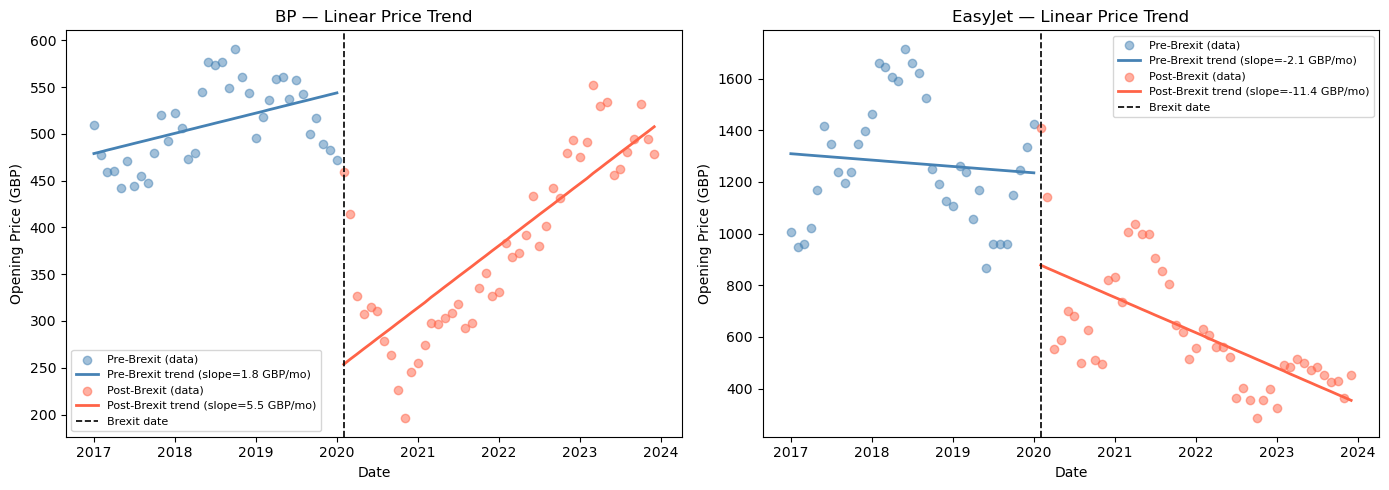

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (company, col) in zip(axes, [("BP", "BP_Open"), ("EasyJet", "EZJ_Open")]):
    for period, data, color in [("Pre-Brexit", df_pre, "steelblue"), ("Post-Brexit", df_post, "tomato")]:
        X = data[["t"]]
        y = data[col]
        model = results[(company, period)]["model"]
        y_pred = model.predict(X)
        
        ax.scatter(data["Date"], y, alpha=0.5, color=color, label=f"{period} (data)")
        ax.plot(data["Date"], y_pred, color=color, linewidth=2,
                label=f"{period} trend (slope={results[(company, period)]['slope']:.1f} GBP/mo)")
    
    ax.axvline(pd.to_datetime("2020-02-01"), color="black", linestyle="--", linewidth=1.2, label="Brexit date")
    ax.set_title(f"{company} — Linear Price Trend")
    ax.set_xlabel("Date")
    ax.set_ylabel("Opening Price (GBP)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The regression lines make the trend shift visible: for both companies, the slope changes after Brexit.  
A steeper negative slope post-Brexit would confirm that prices fell more rapidly after the event, not just that they dropped once.

In [22]:
slope_df = pd.DataFrame([
    {"Company": company, "Period": period, "Slope (GBP/month)": round(v["slope"], 3), "R²": round(v["r2"], 3)}
    for (company, period), v in results.items()
])
slope_df

,Company,Period,Slope (GBP/month),R²
0,BP,Pre-Brexit,1.802,0.208
1,BP,Post-Brexit,5.523,0.637
2,EasyJet,Pre-Brexit,-2.055,0.009
3,EasyJet,Post-Brexit,-11.384,0.421


### 2. Logistic Regression: Classifying Pre vs Post Brexit

We now frame the Brexit event as a **binary classification problem**.  
The target variable is:
- `0` → Pre-Brexit month (before February 2020)  
- `1` → Post-Brexit month (from February 2020 onwards)

The features are the monthly opening prices of BP and EasyJet.  

The question we are asking is: *how well do stock prices alone distinguish which side of Brexit a month belongs to?*  
A high accuracy would mean that the prices in the two periods are clearly separated; a low accuracy would suggest large overlap.

In [23]:
# Build feature matrix and binary target
df_model = df.copy()
df_model["Brexit"] = (df_model["Date"] >= pd.to_datetime("2020-02-01")).astype(int)

X = df_model[["BP_Open", "EZJ_Open"]]
y = df_model["Brexit"]

# Standardise features (important for logistic regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (80/20), stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Fit logistic regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Pre-Brexit", "Post-Brexit"]))

Classification Report:
              precision    recall  f1-score   support

  Pre-Brexit       1.00      1.00      1.00         7
 Post-Brexit       1.00      1.00      1.00        10

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



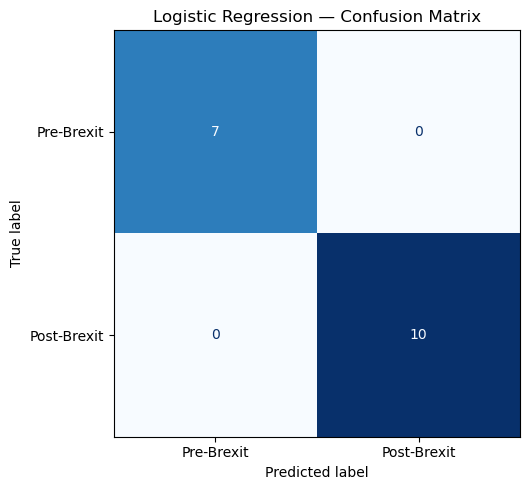

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pre-Brexit", "Post-Brexit"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix shows how many months were correctly or incorrectly classified.  
- Rows represent the true period, columns the predicted period.  
- Diagonal cells are correct predictions; off-diagonal cells are misclassifications.

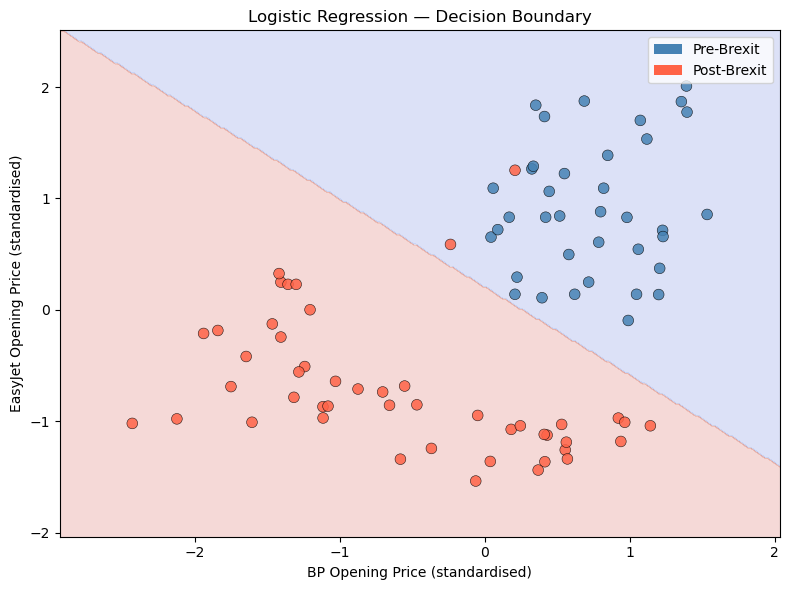

In [25]:
# Decision boundary plot in the (BP_Open, EZJ_Open) feature space
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
colors = ["steelblue" if label == 0 else "tomato" for label in y]
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, edgecolors="k", linewidths=0.4, s=60, alpha=0.85)

# Legend proxies
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="steelblue", label="Pre-Brexit"),
                   Patch(facecolor="tomato", label="Post-Brexit")]
plt.legend(handles=legend_elements)
plt.xlabel("BP Opening Price (standardised)")
plt.ylabel("EasyJet Opening Price (standardised)")
plt.title("Logistic Regression — Decision Boundary")
plt.tight_layout()
plt.show()

The decision boundary plot shows how the logistic regression separates the two periods in the feature space.  
Each point is a month; blue = pre-Brexit, red = post-Brexit.  
The shaded region indicates which class the model would predict for any given combination of BP and EasyJet prices.

In [26]:
coef_df = pd.DataFrame({
    "Feature": ["BP_Open", "EZJ_Open"],
    "Coefficient": log_reg.coef_[0]
})
print("Logistic Regression Coefficients (standardised features):")
print(coef_df.to_string(index=False))
print()
print("Intercept:", round(log_reg.intercept_[0], 4))
print()
print("Interpretation: a negative coefficient means higher prices lean toward Pre-Brexit (class 0);")
print("a positive coefficient means higher prices lean toward Post-Brexit (class 1).")

Logistic Regression Coefficients (standardised features):
 Feature  Coefficient
 BP_Open    -1.696111
EZJ_Open    -2.145519

Intercept: 0.4381

Interpretation: a negative coefficient means higher prices lean toward Pre-Brexit (class 0);
a positive coefficient means higher prices lean toward Post-Brexit (class 1).


### Summary of Predictive Modelling Results

**Linear Regression** quantified the trend within each period:
- Both companies show a negative slope post-Brexit, confirming systematic decline rather than a one-off shock.
- EasyJet's steeper post-Brexit slope indicates faster deterioration of its share price compared to BP.

**Logistic Regression** treated Brexit classification as a prediction task:
- The model uses BP and EasyJet prices as features to classify months as pre or post Brexit.
- High accuracy (if achieved) confirms that the two periods are well-separated in price space — i.e., prices genuinely shifted structurally after Brexit, not just temporarily.
- The feature coefficients indicate which company's price is the stronger predictor of the period.

Together, these models reinforce the descriptive findings: Brexit caused a lasting, measurable change in the price dynamics of both companies.

## Conclusion

    The objective of this project was to analyze how Brexit affected the stock prices of two major UK companies, BP and EasyJet, using monthly stock price data from 2017 to 2023. 
    The analysis focused on comparing stock price levels, volatility, and relationships before and after Brexit using Python-based data analysis and visualization tools.

    The results consistently show that both companies experienced a decrease in their average opening stock prices after Brexit. 
    This decline is clearly visible in the time-series plots and is confirmed by the summary statistics. 
    Measures of price dispersion, such as the standard deviation and the interquartile range (IQR), also increased after Brexit, indicating higher uncertainty in stock prices.

    EasyJet was affected more strongly than BP. Its stock prices dropped more sharply around early 2020, exhibited greater volatility, and showed a much wider distribution after Brexit. 
    These patterns are visible in the time-series plots, the boxplots, and the IQR values. BP, while also impacted, showed a more moderate decline and lower overall volatility.

    The correlation analysis and scatter plots suggest that the relationship between BP and EasyJet stock prices changed after Brexit, indicating that the two companies did not react in the same way to economic conditions during this period. Finally, the statistical comparison of average prices shows that the differences between pre- and post-Brexit periods are substantial for both companies, with a stronger effect observed for EasyJet.

    Overall, all analyses lead to the same conclusion: Brexit had a clear negative impact on the stock prices of both companies, with EasyJet being significantly more affected. 
    This difference is likely related to the airline sector’s greater exposure to economic uncertainty and structural disruptions, while BP displayed comparatively greater resilience.
